# Closed-loop image ordering

SIFT descriptors are matched using reciprocal Lowe-ratio filtering. RANSAC fundamental-matrix verification rejects inconsistent matches. Pair scores combine inlier count, inlier ratio and image coverage. A multistart nearest-neighbor/cheapest-insertion heuristic followed by 2-opt estimates a single closed Hamiltonian cycle.

The last frame reconnects to the first; starting point and direction are inherently arbitrary. Filenames are shuffled identifiers and are never used as adjacency evidence. Both supplied upper-loop RGB scenes contain 25 images. No verified ground-truth ordering was supplied, so geometric support and visual plausibility are reported instead of invented accuracy.

In [1]:
from pathlib import Path
import sys, json, os
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'cvprojects').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
DATA = Path(os.environ.get('CV_DATA_ROOT', str(ROOT / 'data')))
RUN_PIPELINE = False  # set True after downloading the data


In [2]:
from cvprojects.sequence import run
if RUN_PIPELINE:
    for scene in ['easy', 'challenging']:
        run(DATA / 'sequences' / scene / 'upper_loop/rgb', ROOT / 'results/project3' / scene)
for scene in ['easy', 'challenging']:
    result = json.loads((ROOT / 'results/project3' / scene / 'order.json').read_text())
    print(scene, 'frames:', len(result['order']), 'unsupported edges:', result['unsupported_cycle_edges'])
    print(' -> '.join(result['order']) + ' -> [first frame]')

easy frames: 25 unsupported edges: 0
0042.png -> 0035.png -> 0026.png -> 0038.png -> 0028.png -> 0030.png -> 0033.png -> 0048.png -> 0032.png -> 0049.png -> 0031.png -> 0027.png -> 0046.png -> 0025.png -> 0044.png -> 0039.png -> 0043.png -> 0041.png -> 0034.png -> 0037.png -> 0029.png -> 0036.png -> 0045.png -> 0047.png -> 0040.png -> [first frame]
challenging frames: 25 unsupported edges: 0
0047.png -> 0038.png -> 0045.png -> 0033.png -> 0037.png -> 0039.png -> 0048.png -> 0036.png -> 0041.png -> 0030.png -> 0044.png -> 0042.png -> 0031.png -> 0025.png -> 0035.png -> 0026.png -> 0028.png -> 0029.png -> 0034.png -> 0046.png -> 0043.png -> 0027.png -> 0032.png -> 0049.png -> 0040.png -> [first frame]


### Easy

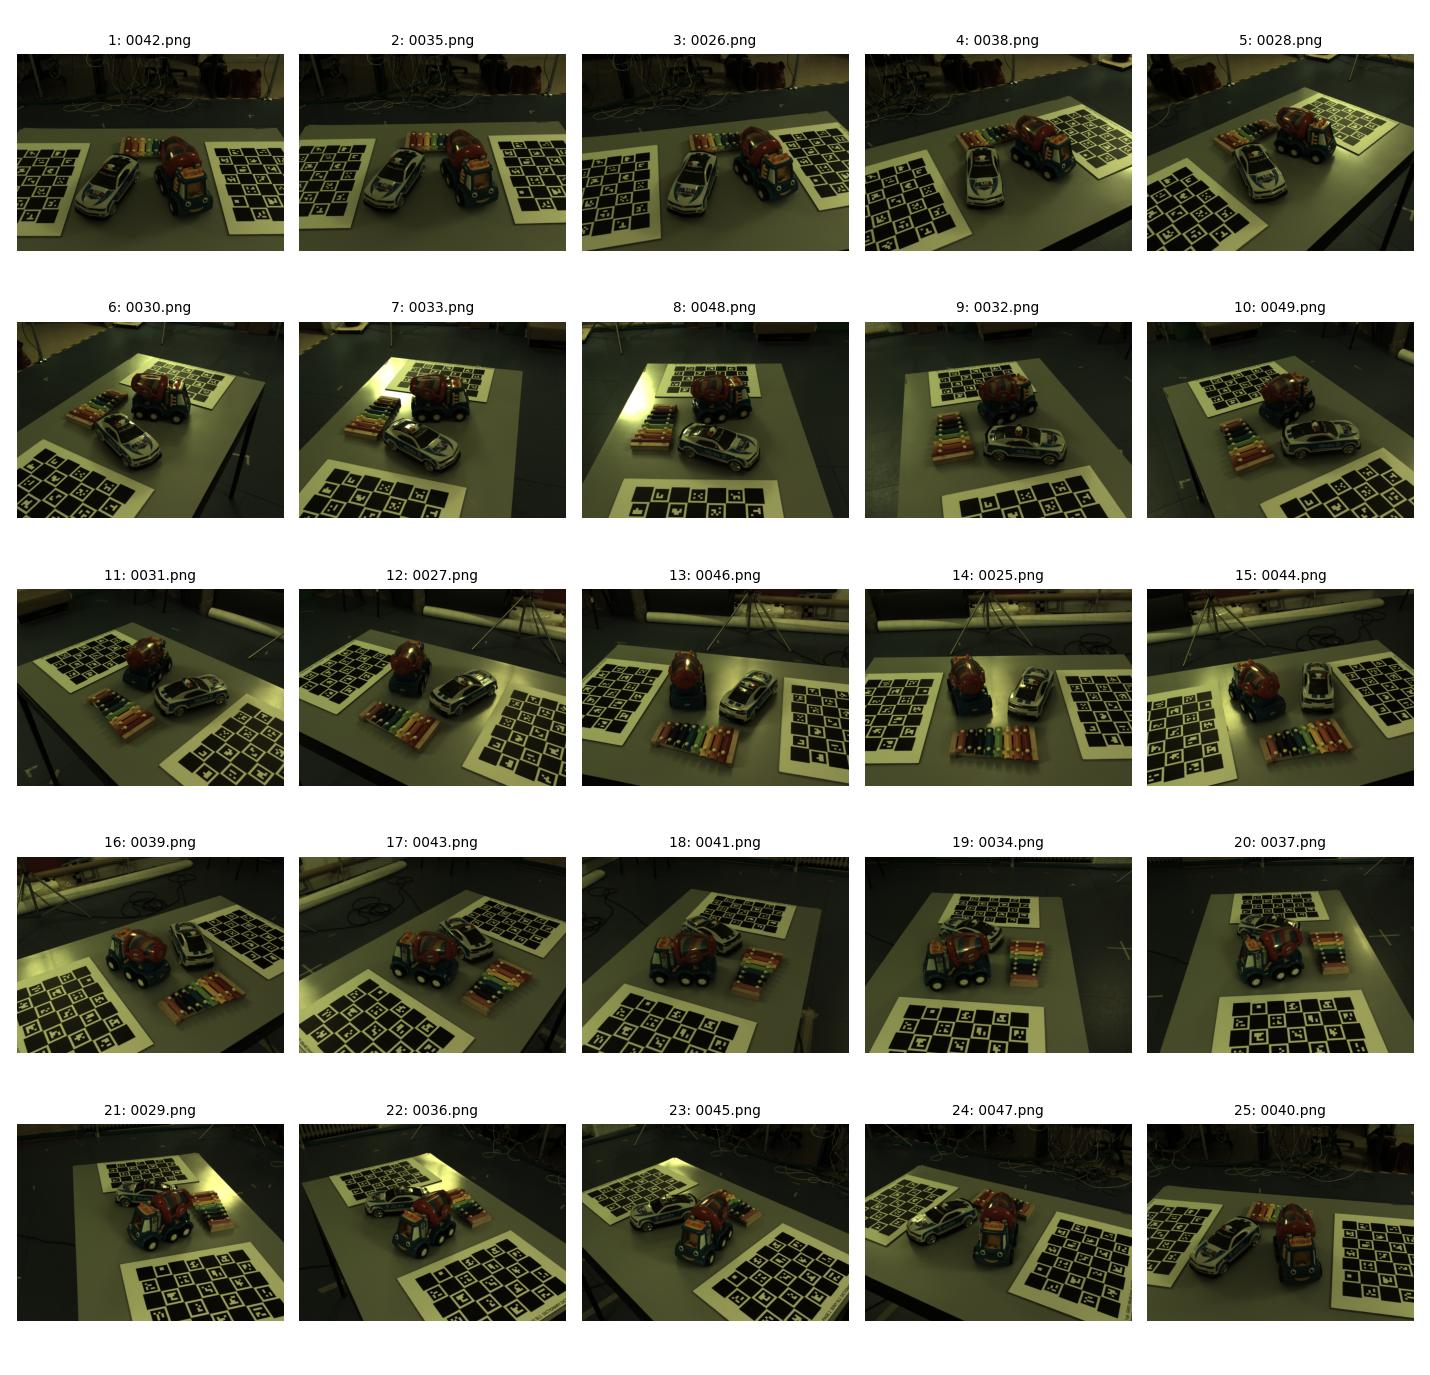

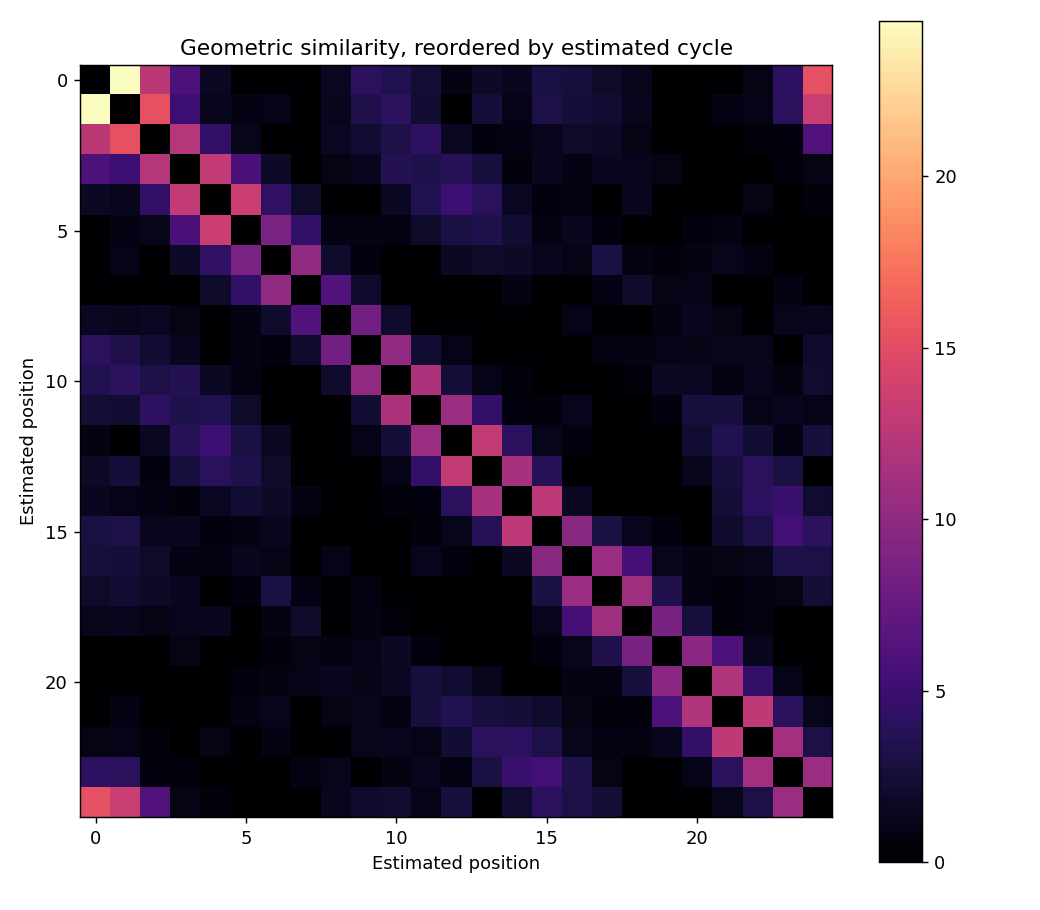

### Challenging

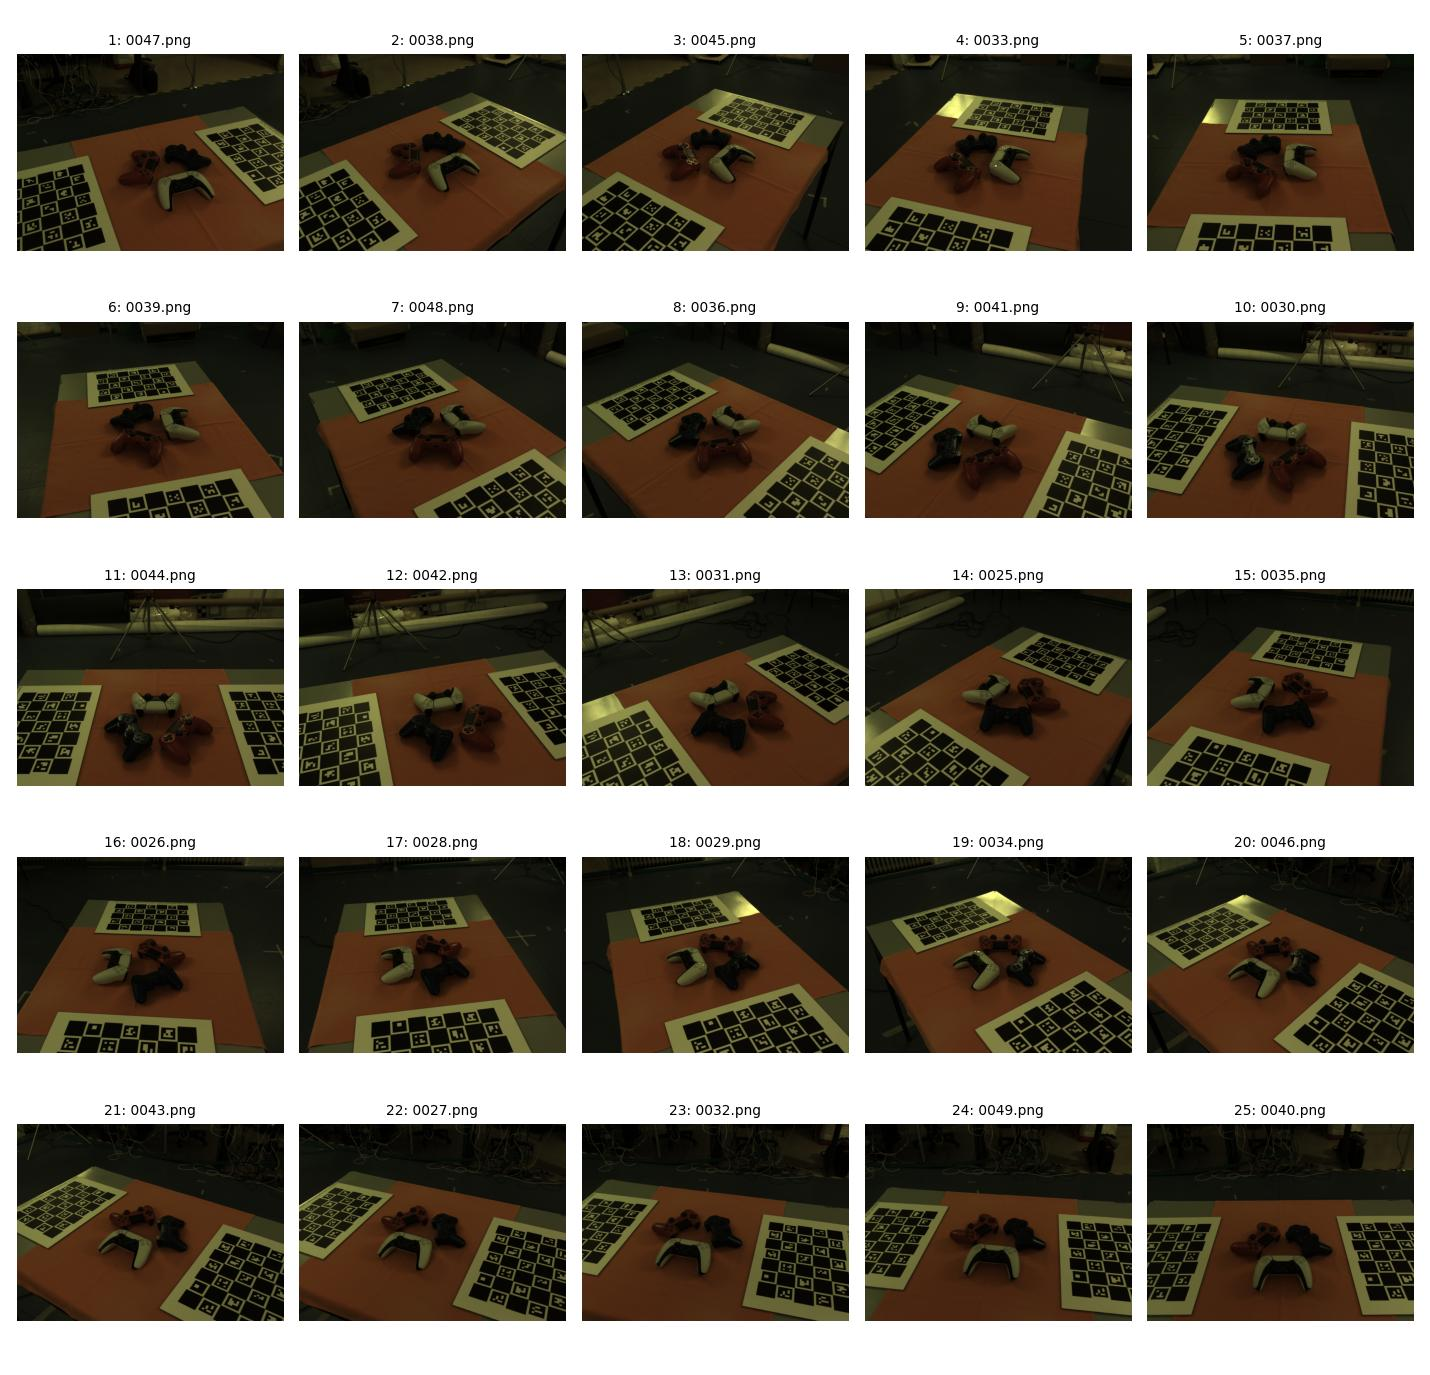

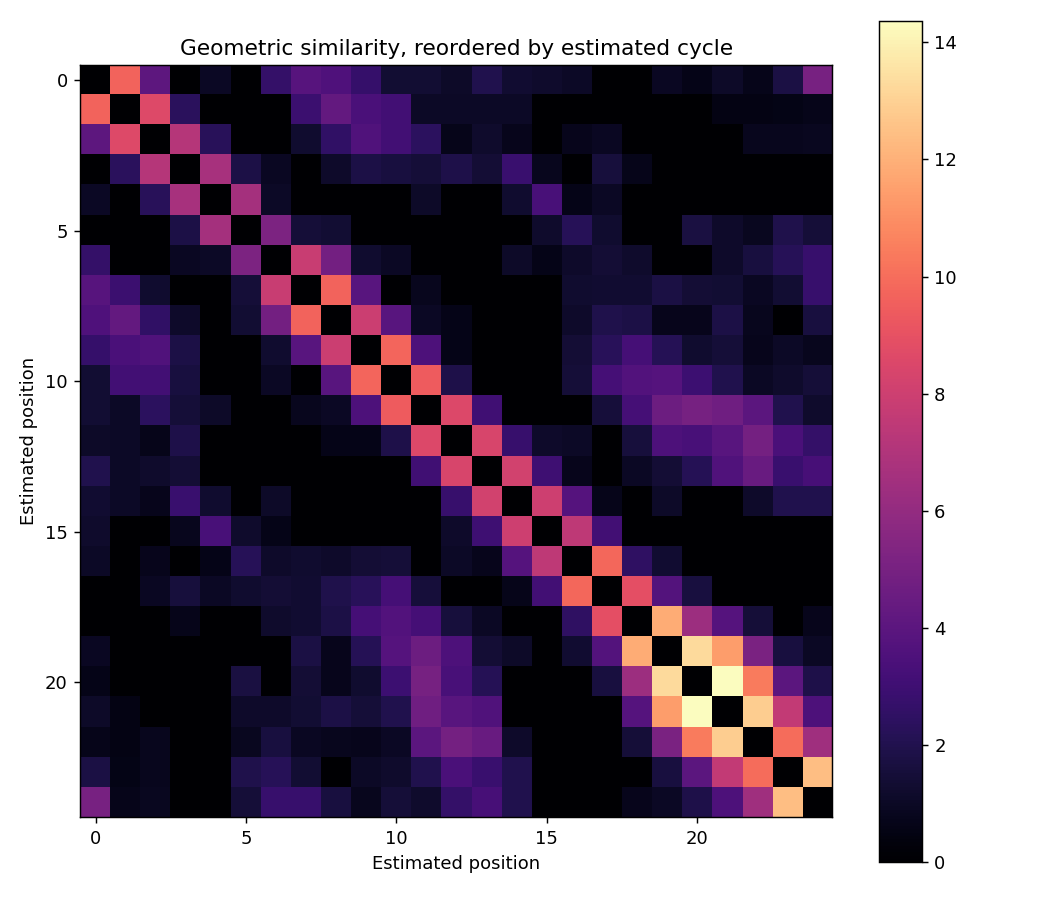

In [3]:
for scene in ['easy', 'challenging']:
    display(Markdown('### ' + scene.capitalize()))
    display(Image(filename=str(ROOT / 'results/project3' / scene / 'estimated_sequence.jpg'), width=1000))
    display(Image(filename=str(ROOT / 'results/project3' / scene / 'similarity.png'), width=650))

## Interpretation and reproduction

See `../docs/RESULTS.md` for the observed results and limitations, and `../README.md` for download/run commands. The saved outputs shown above come from the included experiment. Set `RUN_PIPELINE = True` to regenerate them using local datasets.